<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/02_eda_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**02- EDA and visualization**

This notebook performs exploratory data analysis (EDA) on the cleaned Telco customer churn dataset to visualize patterns, understand feature distributions, and identify relationships between variables and customer churn.

###  1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

###  2. Load the cleaned data

In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,0,1,0,0,0,1,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,1,0,1,0,0,0,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,0,1,0,0,1,0,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,0,0,0,0,1,0,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,1,1,0,0,1,0,0,0,22.38,3


In [13]:
# Check dataset shape
df.shape

(67987, 25)

In [15]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67987 entries, 0 to 67986
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   67987 non-null  int64  
 1   SeniorCitizen                            67987 non-null  int64  
 2   Partner                                  67987 non-null  int64  
 3   Dependents                               67987 non-null  int64  
 4   tenure                                   67987 non-null  float64
 5   PhoneService                             67987 non-null  int64  
 6   MultipleLines                            67987 non-null  int64  
 7   InternetService                          67987 non-null  int64  
 8   OnlineSecurity                           67987 non-null  int64  
 9   OnlineBackup                             67987 non-null  int64  
 10  DeviceProtection                         67987

In [16]:
# Count churn values

#df["Churn"].value_counts()

# **Churn** **Distribution**

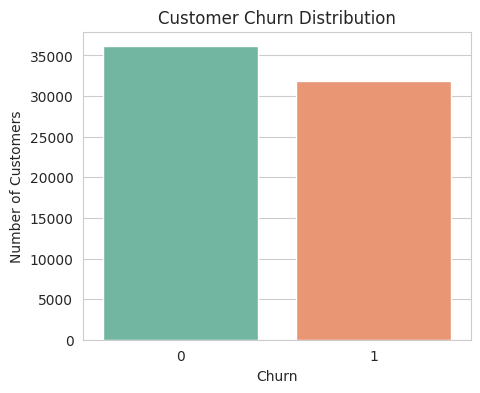

In [17]:
# This plot shows the number of customers who churned vs those who stayed.

plt.figure(figsize=(5,4))

sns.countplot(
    x="Churn",
    data=df,
    hue="Churn",
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()




*  ### Churn by Contract Type

    The dataset shows a relatively balanced distribution between churned and non-churned customers, which is suitable for building a predictive model without severe class imbalance.



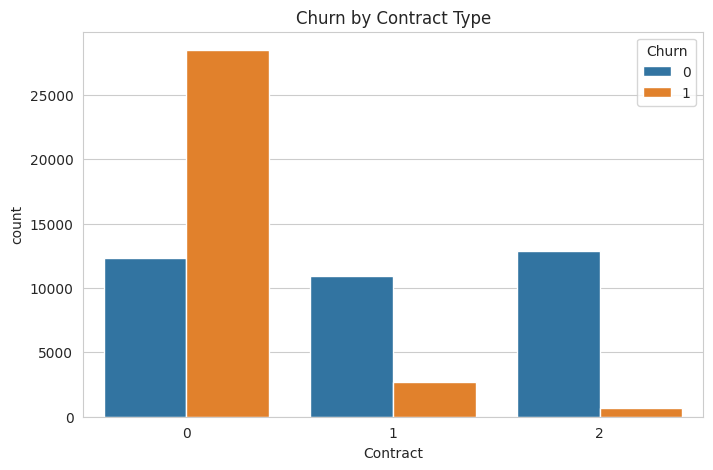

In [18]:
# This plot shows the number of churned vs non-churned customers for each contract type.

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.show()



*   ### Mapping Contract Codes to Contract Names

     Customers with lower tenure tend to churn slightly more frequently than long-term customers, suggesting that new customers may be more likely to leave the service.

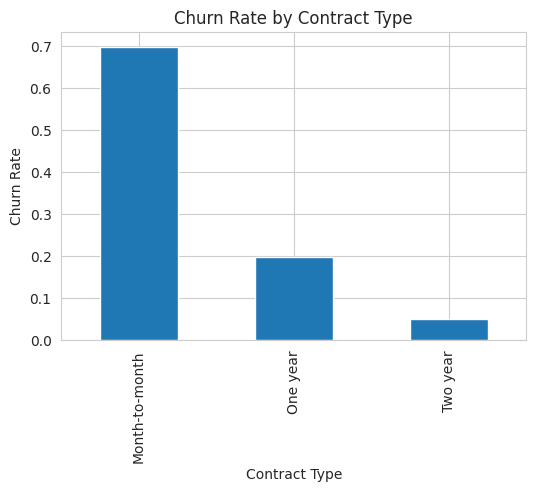

ContractName
Month-to-month    0.697866
One year          0.198649
Two year          0.050454
Name: Churn, dtype: float64


In [19]:
# Convert numerical contract values into readable contract names.

contract_map = {
    0: "Month-to-month",
    1: "One year",
    2: "Two year"
}

df["ContractName"] = df["Contract"].map(contract_map)

# Calculate the churn rate for each contract type.
contract_churn = df.groupby("ContractName")["Churn"].mean()

# Bar chart showing the churn percentage for each contract.
plt.figure(figsize=(6,4))
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

print(contract_churn)

**Insight:**


*  Customers with month-to-month contracts are much more likely to churn compared to customers with longer-term contracts. As the contract duration increases, the churn rate decreases significantly.





*   ## Tenure vs Churn
    Analyze whether new customers churn more frequently.

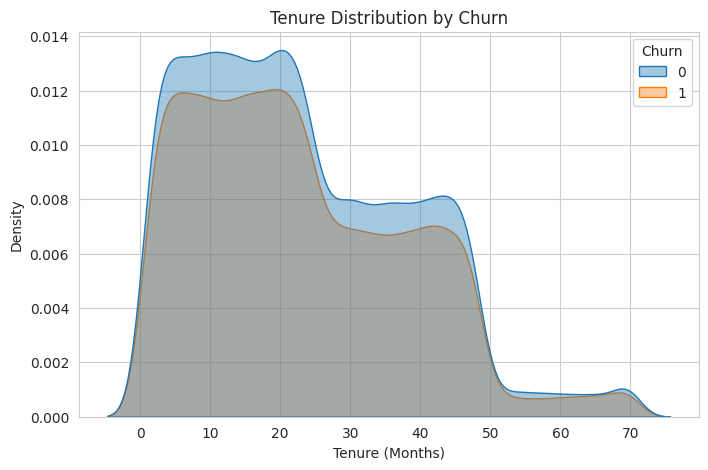

In [20]:
# This shows how customer tenure is distributed for churned vs non-churned customers.

sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, alpha=0.4)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.show()

**Insight:**


* The distribution shows that customers with lower tenure have a higher probability of churn. As tenure increases, the likelihood of churn decreases, indicating that long-term customers are generally more loyal.






*   ### **Create Tenure Groups**




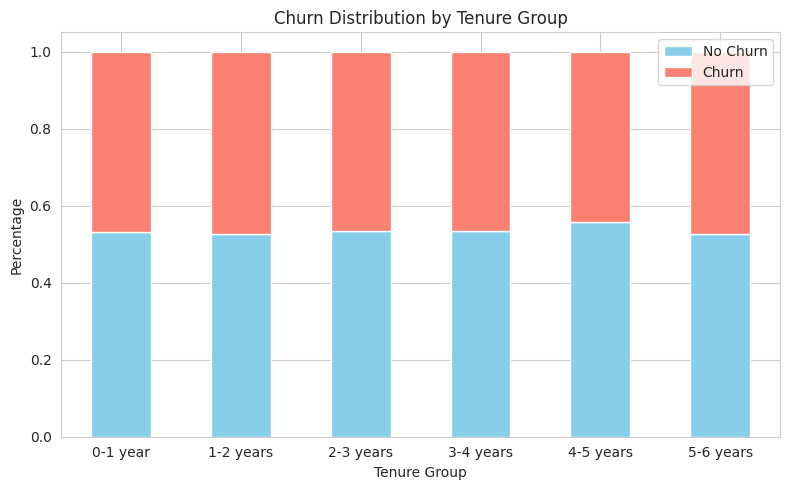

In [21]:
# Convert the tenure (in months) into groups representing years to make the analysis easier to interpret.
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 year"
    elif tenure <= 24:
        return "1-2 years"
    elif tenure <= 36:
        return "2-3 years"
    elif tenure <= 48:
        return "3-4 years"
    elif tenure <= 60:
        return "4-5 years"
    else:
        return "5-6 years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

# Calculate Churn Distribution by Tenure Group
# Compute the percentage of churned and non-churned customers within each tenure group.

order = ["0-1 year", "1-2 years", "2-3 years", "3-4 years", "4-5 years", "5-6 years"]

tenure_counts = (
    df.groupby("TenureGroup")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(order)
)

tenure_counts = tenure_counts[[0, 1]]

# Visualize Churn Distribution by Tenure Group
# Stacked bar chart showing the percentage of churned vs non-churned customers in each tenure category.

tenure_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["skyblue", "salmon"]
)

plt.title("Churn Distribution by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.legend(["No Churn", "Churn"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
* The churn distribution across tenure groups is relatively similar, indicating that tenure alone does not strongly influence churn. This suggests that other features, such as contract type or services used, may have a stronger impact on customer churn.



*   ### Feature Correlation Heatmap




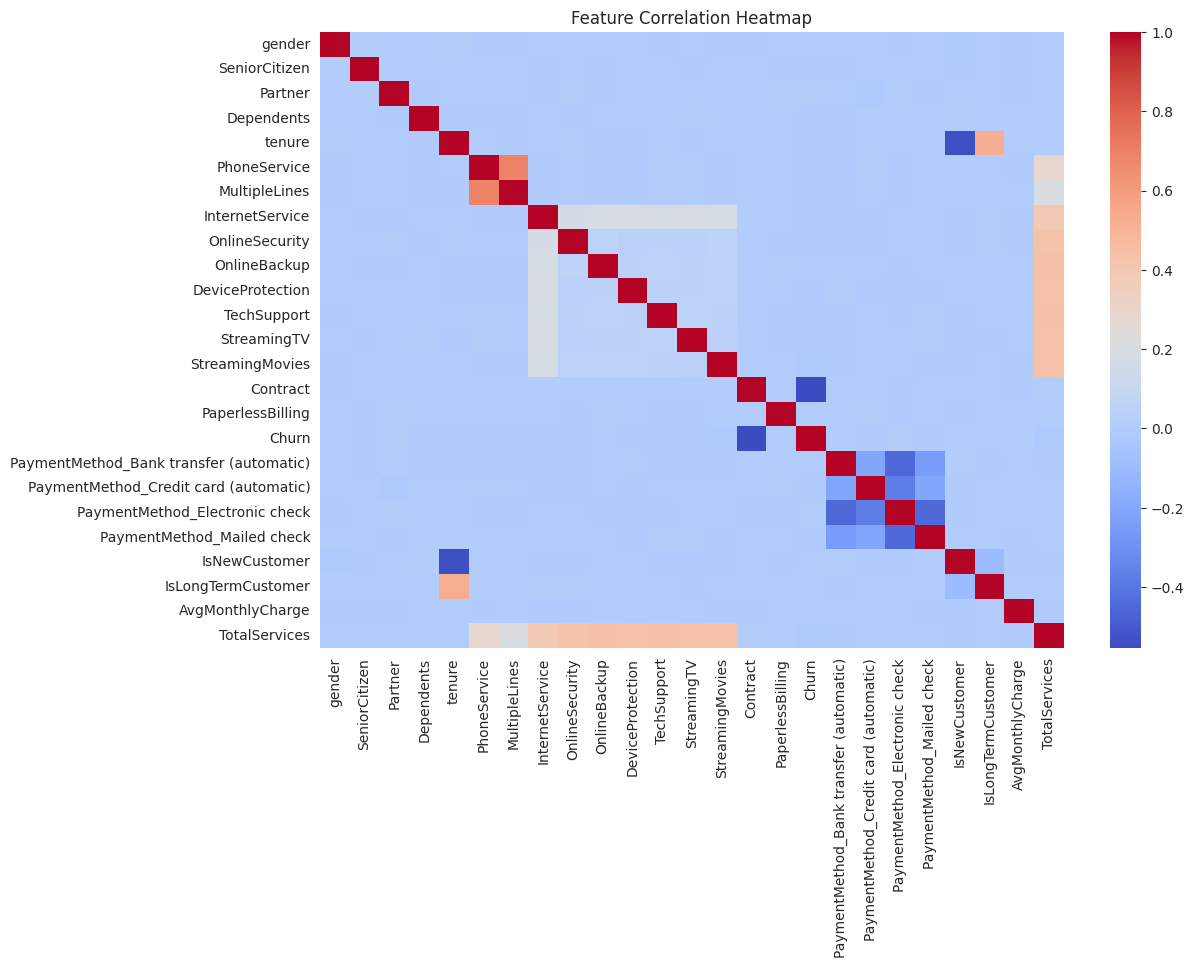

In [22]:
# This heatmap shows the correlation between numerical features in the dataset to identify relationships between variables.
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

**Insight:**

* The correlation heatmap illustrates the relationships between numerical features in the dataset. Strong correlations are observed between MonthlyCharges, AvgMonthlyCharge, and TotalCharges, which is expected since these variables are mathematically related. Additionally, contract type shows a negative relationship with churn, indicating that customers with longer contracts are less likely to leave the service.


*   ### **Churn Rate by Number of Services**




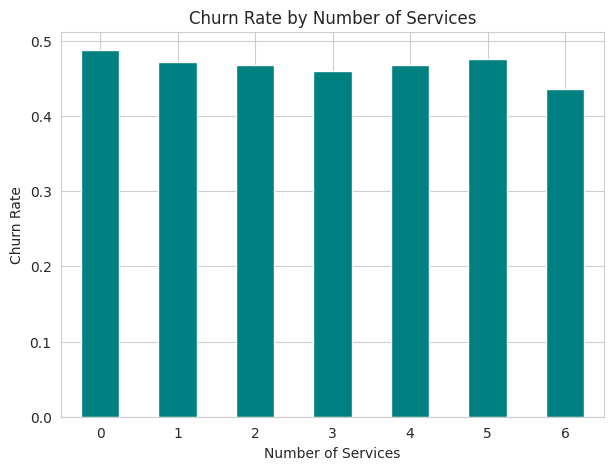

TotalServices
0    0.487643
1    0.471831
2    0.467700
3    0.460166
4    0.467507
5    0.475300
6    0.435294
Name: Churn, dtype: float64


In [23]:
# Calculate the average churn rate for customers based on how many services they use.

services_churn = df.groupby("TotalServices")["Churn"].mean()

plt.figure(figsize=(7,5))
services_churn.plot(kind="bar", color="teal")

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate")

plt.xticks(rotation=0)

plt.show()

print(services_churn)

**Insight:**


*  The churn rate remains fairly consistent across different numbers of services, indicating that the number of services alone is not a strong predictor of customer churn
*   Although customers with more services might be expected to be more loyal, the analysis shows that the churn rate does not change significantly with the number of services.






*   ### **Proportion of Churn by Number of Services**


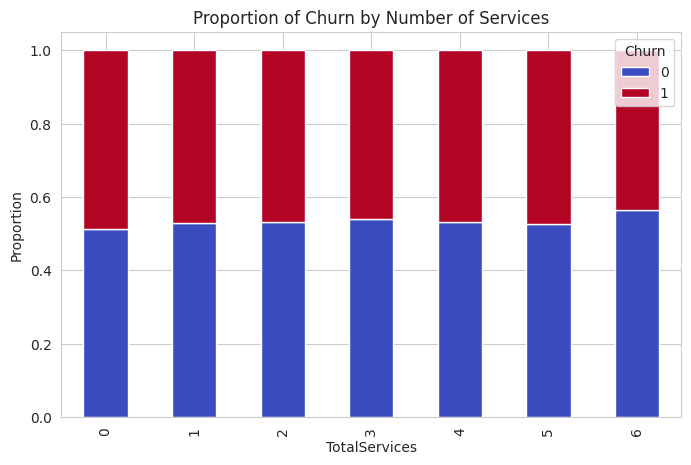

In [24]:
# Crosstab showing the proportion of churned and non-churned customers for each number of subscribed services.

service_churn = pd.crosstab(
    df["TotalServices"],
    df["Churn"],
    normalize="index"
)

service_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="coolwarm"
)

plt.ylabel("Proportion")
plt.title("Proportion of Churn by Number of Services")

plt.show()

**Insight:**


*   The chart shows that most customers subscribe to one or two services. Although customers with fewer services appear slightly more likely to churn, the overall difference between churned and non-churned customers is not very large. This suggests that the number of services alone is not a strong predictor of churn.







* ### **Avg Monthly Charge Distribution by Churn**




<Axes: xlabel='AvgMonthlyCharge', ylabel='Count'>

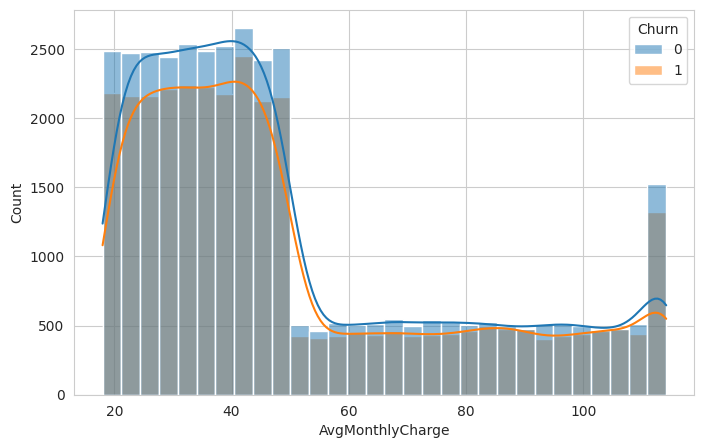

In [25]:
# Histogram showing how the monthly charges are distributed for churned vs non-churned customers.

sns.histplot(data=df, x="AvgMonthlyCharge", hue="Churn", bins=30, kde=True)

**Insight:**


* The distribution of the average monthly charge is very similar for churned and non-churned customers, with a large overlap between the two groups. This suggests that average monthly spending alone does not strongly distinguish customers who churn from those who remain.



*   ### **Churn Rate by Internet Service**




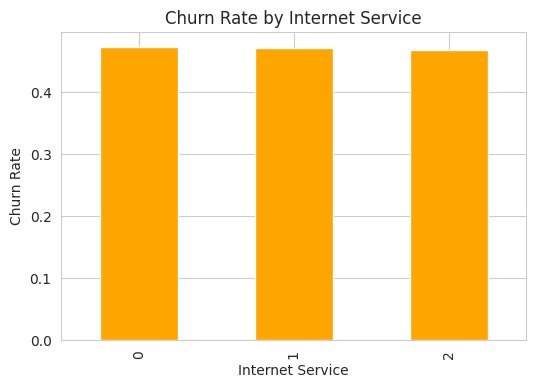

In [26]:
# Calculate the churn rate for each type of internet service.

internet_churn = df.groupby("InternetService")["Churn"].mean()

plt.figure(figsize=(6,4))
internet_churn.plot(kind="bar", color="orange")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.show()

**Insight:**


* The chart shows that most customers use fiber optic internet service. While churn appears slightly higher among fiber optic users compared to other internet types, the differences between the groups are not extremely large. This suggests that internet service type alone may not strongly determine customer churn.



*   ### **Churn by Customer Status (New vs Existing)**




<Axes: xlabel='IsNewCustomer', ylabel='count'>

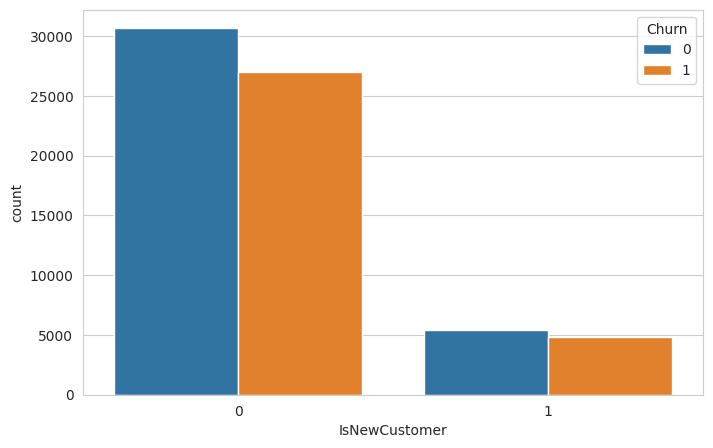

In [27]:
# This plot shows the number of churned and non-churned customers among new customers and existing customers.

sns.countplot(data=df, x="IsNewCustomer", hue="Churn")

The chart shows the distribution of churn among new and existing customers. Although most customers are existing customers, the difference between churned and non-churned customers is relatively similar in both groups. This indicates that the "IsNewCustomer" feature alone may not strongly influence churn behavior.



*  ### **Top Features Correlated with Churn**



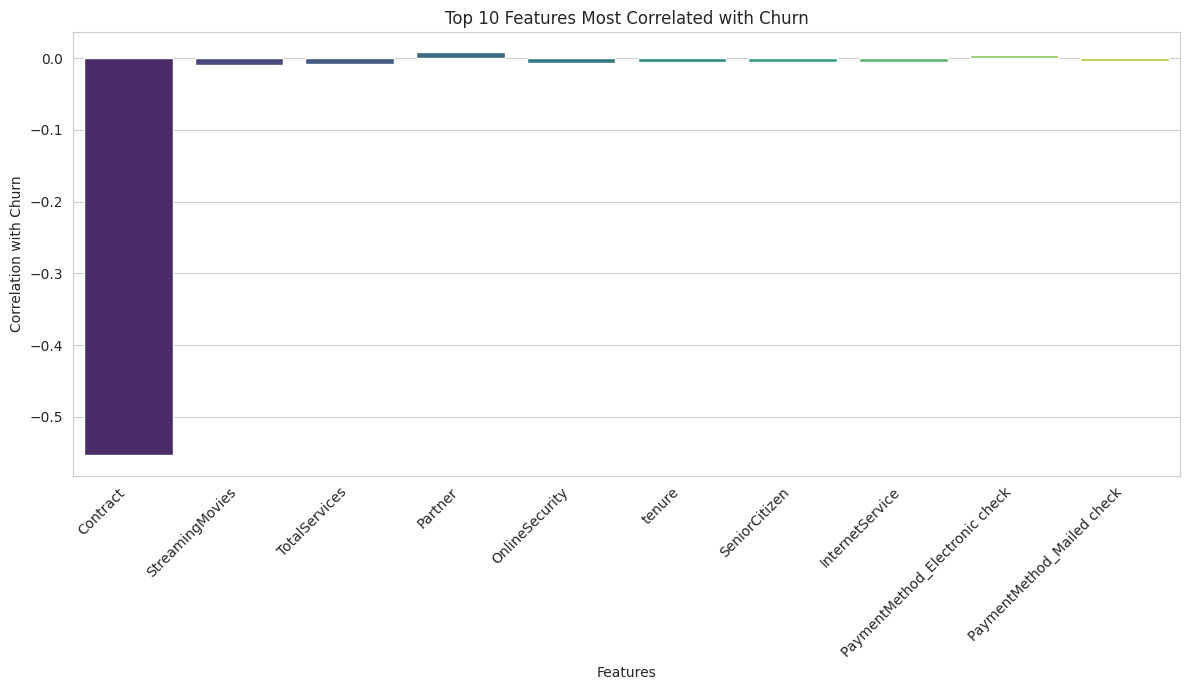


Top 10 features most correlated with Churn:
 Contract                         -0.553862
StreamingMovies                  -0.009780
TotalServices                    -0.008478
Partner                           0.007839
OnlineSecurity                   -0.006801
tenure                           -0.005327
SeniorCitizen                    -0.004991
InternetService                  -0.004821
PaymentMethod_Electronic check    0.004676
PaymentMethod_Mailed check       -0.004347
Name: Churn, dtype: float64


In [28]:
# Compute correlation between numerical features and the Churn variable.
# Features are sorted by absolute correlation strength.

correlation_with_churn = df.corr(numeric_only=True)["Churn"].sort_values(
    key=abs,
    ascending=False
)

# Remove Churn itself
correlation_with_churn = correlation_with_churn.drop("Churn")

# Select top 10 features
top_features = correlation_with_churn.head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_features.index,
    y=top_features.values,
    hue=top_features.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Features Most Correlated with Churn")
plt.xlabel("Features")
plt.ylabel("Correlation with Churn")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

print("\nTop 10 features most correlated with Churn:\n", top_features)

#Summary

First, contract type appears to be one of the strongest indicators of churn. Customers with month-to-month contracts show a significantly higher churn rate compared to customers with one-year or two-year contracts. This suggests that longer contract durations contribute to stronger customer retention and loyalty.

Second, payment methods also show noticeable differences in churn behavior. Customers who use electronic checks tend to have a higher churn rate compared to those who use automatic payment methods such as bank transfers or credit cards. Automated billing appears to be associated with lower churn probability.

Third, monthly charges show a moderate relationship with churn. Customers with higher monthly charges tend to exhibit a slightly higher churn rate, although the difference is not very strong. This suggests that pricing may influence churn but is not the only determining factor.

In contrast, some features such as the number of subscribed services and customer tenure show only limited variation in churn patterns. These variables alone do not clearly distinguish churned customers from retained customers.

Additionally, correlation analysis indicates that most individual features have relatively weak correlations with churn. This suggests that churn is likely influenced by a combination of multiple factors rather than a single dominant variable.

Overall, the analysis highlights contract type, payment method, and billing behavior as some of the most informative indicators of customer churn. These insights provide a strong foundation for the next stage of the project, where machine learning models will be developed to predict churn and identify the most influential predictive features.